# Energy-based Generative Models to learn MNIST

In this notebook, we study the MNIST dataset using energy-based generative models, specifically Restricted Boltzmann Machines (RBMs) and Deep Boltzmann Machines (DBMs).

Generative models, as the name suggests, are useful to generate brand new data (images) by learning how to imitate the ones from a given data set. This is achieved by extracting/learning a set of features which represent the backbone of the entire data and are thus definitive for the particular dataset. These features are encoded in the weights of the model.

Mathematically speaking, generative models are designed and trained to learn an approximation for the probability distribution that generated the data. This task is much more complex and sophisticated than the image recognition/classification task.
Therefore, we approach the problem in a number of steps of increasing complexity.

Below, we analyze four different generative models: the Hopfield Model, a Restricted Boltzmann Machine (RBM), and a Deep Boltzmann Machine (DBM). In all these cases, we first set up and train the models. After that, we compare the results. Last, we open up the black box of each model and visualize a set of features it learned.

In [1]:
import numpy as np

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# fix random seeds for reproducibility
np.random.seed(137)
torch.manual_seed(137)

# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Get the MNIST dataset (again)

We will use the MNIST dataset of handwritten digits to study the Hopfield model and various variants of RBMs.

With `torchvision`, the MNIST dataset is downloaded automatically on first use and cached locally in the `./data` directory. No manual setup is needed.



In [2]:
# We binarize each pixel: values > 0.5 map to 1, otherwise 0.
binarize = transforms.Compose([
    transforms.ToTensor(),                               # (1,28,28), range [0,1]
    transforms.Lambda(lambda x: x.view(-1)),             # flatten -> (784,)
    transforms.Lambda(lambda x: (x > 0.5).float())      # binarize
])

full_train = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=binarize
)

# Split: 95% train, 5% validation
n_train = int(0.95 * len(full_train))
n_val   = len(full_train) - n_train
train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(137)
)

batch_size   = 100
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, drop_last=True)

num_visible = 784   # 28 * 28
print(f'Training samples:   {n_train}')
print(f'Validation samples: {n_val}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 469kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]

Training samples:   57000
Validation samples: 3000


## Processing the Data

The `DataLoader` objects above act as our minibatch generators, splitting the data into training and validation sets with automatic shuffling. Each minibatch contains binarized pixel values in $\{0, 1\}$, ready to feed directly into a Bernoulli-Gaussian RBM.

We now move on to construct a `Hopfield` model. To do this, we use the `RBM` class with a visible `BernoulliLayer` and a hidden `GaussianLayer`. Note that the visible layer has the same size as the input data points, `num_visible = 784`. The number of hidden units is `num_hidden_units`. We also set the mean and variance of the Gaussian layer to zero and unity, respectively.

To ensure convergence, we attenuate the `learning_rate` hyperparameter according to a `PowerLawDecay` schedule:
$$\text{learning\_rate}(t) = \frac{\text{initial}}{1 + \text{coefficient} \times t}$$
We define the special function `make_adam_optimizer()` for this purpose.

In [3]:
# RBM class
class RBM:
    """
    Restricted Boltzmann Machine.

    Visible units : always Bernoulli  (v_i in {0,1})
    Hidden units  : Bernoulli ('bernoulli') or Gaussian ('gaussian')

    The Hopfield model is the special case hidden_type='gaussian',
    where the Gaussian mean and variance are fixed at 0 and 1.
    """

    def __init__(self, n_visible, n_hidden,
                 hidden_type='bernoulli', l1_penalty=0.0):
        self.n_visible   = n_visible
        self.n_hidden    = n_hidden
        self.hidden_type = hidden_type
        self.l1_penalty  = l1_penalty

        # Glorot (Xavier) normal initialization
        std = np.sqrt(2.0 / (n_visible + n_hidden))
        self.W = torch.randn(n_visible, n_hidden, device=device) * std
        self.a = torch.zeros(n_visible, device=device)   # visible biases
        self.b = torch.zeros(n_hidden,  device=device)   # hidden biases

    def init_from_data(self, data_loader):
        total = torch.zeros(self.n_visible, device=device)
        n = 0
        for v, _ in data_loader:
            total += v.to(device).sum(0)
            n     += v.shape[0]
        p = (total / n).clamp(0.01, 0.99)
        self.a = torch.log(p / (1.0 - p))

    # Conditional probability calculations
    def prob_h_given_v(self, v):
        """Mean activation of hidden units given v."""
        pre = v @ self.W + self.b
        return torch.sigmoid(pre) if self.hidden_type == 'bernoulli' else pre

    def prob_v_given_h(self, h):
        """P(v=1|h) for Bernoulli visible units."""
        return torch.sigmoid(h @ self.W.t() + self.a)

    def sample_h(self, v):
        """Draw sample from p(h|v). Returns (sample, mean)."""
        mean_h = self.prob_h_given_v(v)
        if self.hidden_type == 'bernoulli':
            return torch.bernoulli(mean_h), mean_h
        else:   # Gaussian: h ~ N(mean_h, 1)
            return mean_h + torch.randn_like(mean_h), mean_h

    def sample_v(self, h):
        """Draw sample from p(v|h). Returns (sample, mean)."""
        mean_v = self.prob_v_given_h(h)
        return torch.bernoulli(mean_v), mean_v

    # Mean-field reconstruction  v -> <h> -> <v'>
    def reconstruct(self, v):
        return self.prob_v_given_h(self.prob_h_given_v(v))

    def reconstruction_error(self, v):
        with torch.no_grad():
            return ((v - self.reconstruct(v)) ** 2).mean().item()

    def parameters(self):
        return [self.W, self.a, self.b]


# Number of hidden units (shared across all models)
num_hidden_units = 200

# Hopfield model: Bernoulli visible + Gaussian hidden
hopfield = RBM(num_visible, num_hidden_units, hidden_type='gaussian')
hopfield.init_from_data(train_loader)

# Power-law learning rate schedule  lr(t) = initial / (1 + coefficient * t)
def make_adam_optimizer(params, initial=1e-2, coefficient=1.0):
    """
    Wraps a list of tensors as nn.Parameters and returns an (optimizer, scheduler).
    The LambdaLR scheduler applies  lr(epoch) = initial / (1 + coefficient * epoch).
    """
    nn_params = [torch.nn.Parameter(p) for p in params]
    opt = torch.optim.Adam(nn_params, lr=initial)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lr_lambda=lambda t: 1.0 / (1.0 + coefficient * t)
    )
    return nn_params, opt, sched

# Compiling and Training a Model

Next, we define the training loop. The procedure closely follows the recipe from Section 15.5 of Mehta et al.:

1. Read a minibatch of data $\{\mathbf{v}\}$.
2. Compute the positive phase: clamp $\mathbf{v}$ to the data and evaluate $\langle h_\mu \rangle_{p(\mathbf{h}|\mathbf{v})}$ analytically.
3. Compute the negative phase: run $k$ steps of block Gibbs sampling to obtain fantasy particles and evaluate $\langle v_i h_\mu \rangle_\text{model}$.
4. Update parameters using the gradient $\nabla_W L = \langle v_i h_\mu \rangle_\text{data} - \langle v_i h_\mu \rangle_\text{model}$ via Adam.

In [4]:
num_epochs        = 20  # training epochs
monte_carlo_steps = 1   # Gibbs steps per update (CD-k)

def train_model(model, num_epochs, monte_carlo_steps,
                lr_initial=1e-2, lr_coeff=1.0):
    """
    Train a shallow RBM (or Hopfield model) with Persistent Contrastive Divergence.

    Args:
        model             : an RBM instance
        num_epochs        : number of passes over the training data
        monte_carlo_steps : number of block Gibbs steps per CD update (CD-k)
        lr_initial        : initial Adam learning rate
        lr_coeff          : coefficient in the power-law decay schedule
    """
    # Wrap raw tensors as nn.Parameters so Adam can update them
    [W_p, a_p, b_p], opt, scheduler = make_adam_optimizer(
        model.parameters(), initial=lr_initial, coefficient=lr_coeff
    )
    model.W, model.a, model.b = W_p, a_p, b_p

    # PCD persistent chains: start from uniformly random binary states
    persistent_v = (torch.rand(batch_size, model.n_visible, device=device) > 0.5).float()

    for epoch in range(1, num_epochs + 1):

        for v0, _ in train_loader:
            v0 = v0.to(device)

            with torch.no_grad():
                # --- positive phase ---
                # Clamp v to data; compute mean hidden activations analytically
                mean_h_pos = model.prob_h_given_v(v0)

                # --- negative phase (PCD) ---
                # Run k block-Gibbs steps from the persistent fantasy particles
                vk = persistent_v
                for _ in range(monte_carlo_steps):
                    hk, _ = model.sample_h(vk)
                    vk, _ = model.sample_v(hk)
                persistent_v = vk.detach()   # carry forward for next minibatch
                mean_h_neg = model.prob_h_given_v(vk)

                # --- log-likelihood gradients ---
                # dL/dW = <v h>_data - <v h>_model
                grad_W = (v0.t() @ mean_h_pos - vk.t() @ mean_h_neg) / batch_size
                grad_a = (v0 - vk).mean(0)
                grad_b = (mean_h_pos - mean_h_neg).mean(0)

                # L1 penalty: subtract lambda * sign(W) from weight gradient
                if model.l1_penalty > 0.0:
                    grad_W = grad_W - model.l1_penalty * W_p.sign()

                # Adam maximizes likelihood, so negate for gradient *descent*
                W_p.grad = -grad_W
                a_p.grad = -grad_a
                b_p.grad = -grad_b

            opt.step()
            opt.zero_grad()

        scheduler.step()

        # --- validation reconstruction error ---
        val_err, n_batches = 0.0, 0
        for val_v, _ in val_loader:
            val_err   += model.reconstruction_error(val_v.to(device))
            n_batches += 1
        val_err /= n_batches

        print(f'End of epoch {epoch:2d}: '
              f'val_reconstruction_error={val_err:.6f}')


# train hopfield model
train_model(hopfield, num_epochs, monte_carlo_steps)

End of epoch  1: val_reconstruction_error=0.055565
End of epoch  2: val_reconstruction_error=0.042509
End of epoch  3: val_reconstruction_error=0.043134
End of epoch  4: val_reconstruction_error=0.029114
End of epoch  5: val_reconstruction_error=0.026131
End of epoch  6: val_reconstruction_error=0.029466
End of epoch  7: val_reconstruction_error=0.025332
End of epoch  8: val_reconstruction_error=0.020563
End of epoch  9: val_reconstruction_error=0.020980
End of epoch 10: val_reconstruction_error=0.020063
End of epoch 11: val_reconstruction_error=0.018889
End of epoch 12: val_reconstruction_error=0.017909
End of epoch 13: val_reconstruction_error=0.017286
End of epoch 14: val_reconstruction_error=0.016846
End of epoch 15: val_reconstruction_error=0.016097
End of epoch 16: val_reconstruction_error=0.015114
End of epoch 17: val_reconstruction_error=0.015787
End of epoch 18: val_reconstruction_error=0.013594
End of epoch 19: val_reconstruction_error=0.013446
End of epoch 20: val_reconstruc

## More Generative Models

We can also create a Bernoulli RBM and train it using the functions defined above.

In [5]:
##### Bernoulli RBM
rbm = RBM(num_visible, num_hidden_units, hidden_type='bernoulli')
rbm.init_from_data(train_loader)

# train Bernoulli RBM
train_model(rbm, num_epochs, monte_carlo_steps)

End of epoch  1: val_reconstruction_error=0.055960
End of epoch  2: val_reconstruction_error=0.047082
End of epoch  3: val_reconstruction_error=0.042610
End of epoch  4: val_reconstruction_error=0.038530
End of epoch  5: val_reconstruction_error=0.036456
End of epoch  6: val_reconstruction_error=0.035916
End of epoch  7: val_reconstruction_error=0.032774
End of epoch  8: val_reconstruction_error=0.031728
End of epoch  9: val_reconstruction_error=0.030554
End of epoch 10: val_reconstruction_error=0.029408
End of epoch 11: val_reconstruction_error=0.028570
End of epoch 12: val_reconstruction_error=0.027747
End of epoch 13: val_reconstruction_error=0.027351
End of epoch 14: val_reconstruction_error=0.026552
End of epoch 15: val_reconstruction_error=0.026152
End of epoch 16: val_reconstruction_error=0.025744
End of epoch 17: val_reconstruction_error=0.025288
End of epoch 18: val_reconstruction_error=0.024988
End of epoch 19: val_reconstruction_error=0.024839
End of epoch 20: val_reconstruc

To define a Deep Boltzmann Machine (DBM), we just add more layers.

Recalling the essential trick with layer-wise pre-training to prepare the weights of the DBM, we define a `pretrain_layer()` helper which trains each adjacent pair of layers as a standalone RBM. This results in a slight modification of the training function `train_model`, which we call `train_deep_model`.

In [7]:
# Deep Boltzmann Machine
class DBM:
    """
    Deep Boltzmann Machine with an arbitrary number of Bernoulli hidden layers.

    Architecture (bipartite stack, no intra-layer connections at any level):
        v  <->  h^(1)  <->  h^(2)  <->  ...  <->  h^(L)

    Training: layer-wise RBM pre-training followed by PCD fine-tuning.
    """

    def __init__(self, layer_sizes, l1_penalty=1e-3):
        """
        Args:
            layer_sizes (list of int): sizes of every layer, e.g. [784, 200, 200].
            l1_penalty  (float)     : L1 regularisation on all weight matrices.
        """
        self.layer_sizes = layer_sizes
        self.n_layers    = len(layer_sizes)
        self.l1_penalty  = l1_penalty

        # One weight matrix and one bias per inter-layer connection
        self.W = []
        for i in range(self.n_layers - 1):
            std = np.sqrt(2.0 / (layer_sizes[i] + layer_sizes[i + 1]))
            self.W.append(
                torch.randn(layer_sizes[i], layer_sizes[i + 1], device=device) * std
            )
        self.b = [torch.zeros(s, device=device) for s in layer_sizes]

    def parameters(self):
        return self.W + self.b

    # Mean-field forward pass: v -> <h^(1)> -> <h^(2)> -> ...
    def forward_pass(self, v):
        """Returns list of mean activations at every layer given visible input v."""
        acts = [v]
        for i in range(self.n_layers - 1):
            acts.append(torch.sigmoid(acts[-1] @ self.W[i] + self.b[i + 1]))
        return acts

    # Full forward-backward reconstruction:
    #   v -> <h^(1)> -> ... -> <h^(L)>  then back down to <v'>
    def reconstruct(self, v):
        acts = self.forward_pass(v)
        current = acts[-1]
        for i in reversed(range(self.n_layers - 1)):
            current = torch.sigmoid(current @ self.W[i].t() + self.b[i])
        return current

    def reconstruction_error(self, v):
        with torch.no_grad():
            return ((v - self.reconstruct(v)) ** 2).mean().item()

    # One full block Gibbs sweep across all layers
    def gibbs_step(self, states):
        """
        One block Gibbs sweep. Each hidden layer is sampled conditioned on
        its neighbours (the layer above and the layer below).

        Args:    states -- list of tensors, one per layer
        Returns: updated list of states
        """
        new = [s.clone() for s in states]

        # Update each hidden layer (indices 1 .. L)
        for i in range(1, self.n_layers):
            pre = new[i - 1] @ self.W[i - 1] + self.b[i]   # contribution from below
            if i < self.n_layers - 1:                        # contribution from above
                pre = pre + new[i + 1] @ self.W[i].t()
            new[i] = torch.bernoulli(torch.sigmoid(pre))

        # Update visible layer from h^(1)
        new[0] = torch.bernoulli(
            torch.sigmoid(new[1] @ self.W[0].t() + self.b[0])
        )
        return new


##### Deep Boltzmann Machine
# set up the model
dbm = DBM([num_visible, num_hidden_units, num_hidden_units], l1_penalty=1e-3)


# Layer-wise pretraining + PCD fine-tuning
def train_deep_model(model, num_epochs, monte_carlo_steps):
    """
    Train a DBM using:
      (1) Layer-wise RBM pre-training  [Hinton et al. 2006]
      (2) Full PCD fine-tuning

    Pre-training: treat each adjacent pair of layers as a standalone RBM and
    train it with PCD.  The mean hidden activations from the trained lower RBM
    serve as the 'data' for training the next RBM up.  This initialises all
    weights in a sensible basin before joint fine-tuning begins.
    """

    # layer-wise pretraining
    print('=== Layer-wise pretraining ===')

    # Collect all training activations into one tensor for the current layer.
    # Starts with the raw pixel data.
    current_data = torch.cat(
        [v.to(device) for v, _ in train_loader], dim=0
    )  # shape (n_train, layer_size)

    for layer_idx in range(len(model.W)):
        n_vis = model.layer_sizes[layer_idx]
        n_hid = model.layer_sizes[layer_idx + 1]
        print(f'  Pretraining layer {layer_idx} -> {layer_idx + 1}  '
              f'({n_vis} -> {n_hid} units)')

        # Build a temporary standalone RBM for this layer pair
        temp = RBM(n_vis, n_hid, hidden_type='bernoulli',
                   l1_penalty=model.l1_penalty)
        # Initialise visible biases from current-layer data statistics
        p = current_data.mean(0).clamp(0.01, 0.99)
        temp.a = torch.log(p / (1.0 - p))

        [W_p, a_p, b_p], opt, sched = make_adam_optimizer(
            temp.parameters(), initial=1e-2, coefficient=1.0
        )
        temp.W, temp.a, temp.b = W_p, a_p, b_p

        persistent_v = (
            torch.rand(batch_size, n_vis, device=device) > 0.5
        ).float()

        act_loader = DataLoader(
            torch.utils.data.TensorDataset(
                current_data, torch.zeros(current_data.shape[0])
            ),
            batch_size=batch_size, shuffle=True, drop_last=True
        )

        for epoch in range(1, num_epochs + 1):
            for v0, _ in act_loader:
                v0 = v0.to(device)
                with torch.no_grad():
                    mean_h_pos = temp.prob_h_given_v(v0)

                    vk = persistent_v
                    for _ in range(monte_carlo_steps):
                        hk, _ = temp.sample_h(vk)
                        vk, _ = temp.sample_v(hk)
                    persistent_v = vk.detach()
                    mean_h_neg = temp.prob_h_given_v(vk)

                    grad_W = (v0.t() @ mean_h_pos - vk.t() @ mean_h_neg) / batch_size
                    grad_a = (v0 - vk).mean(0)
                    grad_b = (mean_h_pos - mean_h_neg).mean(0)
                    if temp.l1_penalty > 0:
                        grad_W = grad_W - temp.l1_penalty * W_p.sign()

                    W_p.grad = -grad_W
                    a_p.grad = -grad_a
                    b_p.grad = -grad_b

                opt.step()
                opt.zero_grad()
            sched.step()

        # Copy pretrained weights into the DBM
        with torch.no_grad():
            model.W[layer_idx]     = W_p.data.clone()
            model.b[layer_idx]     = a_p.data.clone()
            model.b[layer_idx + 1] = b_p.data.clone()

        # Generate next layer's 'data' from mean hidden activations
        with torch.no_grad():
            current_data = temp.prob_h_given_v(current_data)

    # Fine-tuning of the full DBM
    print('=== Fine-tuning full DBM ===')

    all_params, opt_fine, sched_fine = make_adam_optimizer(
        model.parameters(), initial=1e-3, coefficient=1.0
    )
    n_W = len(model.W)
    # Remap wrapped parameters back into model
    for i in range(n_W):
        model.W[i] = all_params[i]
    for i in range(len(model.b)):
        model.b[i] = all_params[n_W + i]

    # Persistent chains for all layers
    persistent = [
        (torch.rand(batch_size, s, device=device) > 0.5).float()
        for s in model.layer_sizes
    ]

    for epoch in range(1, num_epochs + 1):

        for v0, _ in train_loader:
            v0 = v0.to(device)
            with torch.no_grad():
                # Positive phase: mean-field up-pass clamped to data
                pos_acts = model.forward_pass(v0)

                # Negative phase: one Gibbs sweep on persistent chains
                persistent = model.gibbs_step(persistent)
                neg_acts   = model.forward_pass(persistent[0])

                opt_fine.zero_grad()
                for i, W in enumerate(model.W):
                    grad_W = (
                        pos_acts[i].t() @ pos_acts[i + 1] -
                        neg_acts[i].t() @ neg_acts[i + 1]
                    ) / batch_size
                    if model.l1_penalty > 0:
                        grad_W = grad_W - model.l1_penalty * W.sign()
                    W.grad = -grad_W
                for i, b in enumerate(model.b):
                    b.grad = -(pos_acts[i] - neg_acts[i]).mean(0)

            opt_fine.step()

        sched_fine.step()

        val_err, n_batches = 0.0, 0
        for val_v, _ in val_loader:
            val_err   += model.reconstruction_error(val_v.to(device))
            n_batches += 1
        val_err /= n_batches

        print(f'End of epoch {epoch:2d}: '
              f'val_reconstruction_error={val_err:.6f}')


# train DBM
train_deep_model(dbm, num_epochs, monte_carlo_steps)

=== Layer-wise pretraining ===
  Pretraining layer 0 -> 1  (784 -> 200 units)
  Pretraining layer 1 -> 2  (200 -> 200 units)
=== Fine-tuning full DBM ===
End of epoch  1: val_reconstruction_error=0.040165
End of epoch  2: val_reconstruction_error=0.040905
End of epoch  3: val_reconstruction_error=0.047526
End of epoch  4: val_reconstruction_error=0.063575
End of epoch  5: val_reconstruction_error=0.073902
End of epoch  6: val_reconstruction_error=0.083047
End of epoch  7: val_reconstruction_error=0.084787
End of epoch  8: val_reconstruction_error=0.087153
End of epoch  9: val_reconstruction_error=0.089883
End of epoch 10: val_reconstruction_error=0.088331
End of epoch 11: val_reconstruction_error=0.085516
End of epoch 12: val_reconstruction_error=0.083343
End of epoch 13: val_reconstruction_error=0.085451
End of epoch 14: val_reconstruction_error=0.085651
End of epoch 15: val_reconstruction_error=0.087940
End of epoch 16: val_reconstruction_error=0.094882
End of epoch 17: val_reconstru

## Visualizing the MNIST Dataset

Let us look at a couple of random examples to get some idea about what the data we are looks like.

To do this, we define the function `plot_image_grid()`.

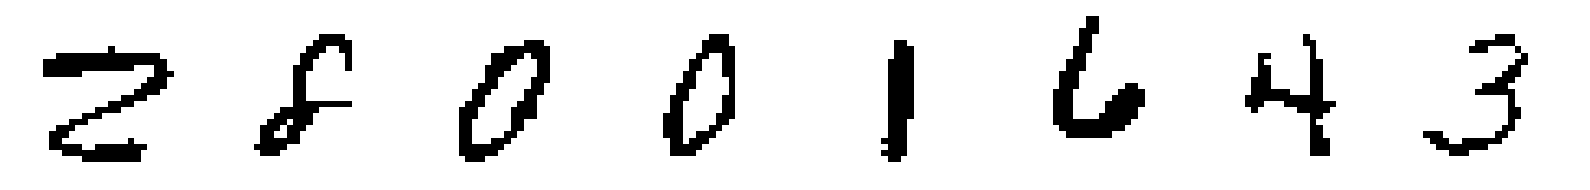

In [8]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import matplotlib.cm as cm
import seaborn as sns


def plot_image_grid(image_array, shape, vmin=0, vmax=1,
                    cmap=cm.gray_r, row_titles=None):
    """
    Plot a 2-D grid of images.

    Args:
        image_array : array-like of shape (nrows, ncols, n_pixels)
        shape       : (height, width) of a single image, e.g. (28, 28)
        vmin, vmax  : colour-scale limits
        cmap        : matplotlib colormap
        row_titles  : optional list of strings, one per row
    """
    if isinstance(image_array, torch.Tensor):
        array = image_array.detach().cpu().numpy()
    else:
        array = np.asarray(image_array)

    nrows, ncols = array.shape[0], array.shape[1]
    f    = plt.figure(figsize=(2 * ncols, 2 * nrows))
    grid = gs.GridSpec(nrows, ncols)
    axes = [[plt.subplot(grid[i, j]) for j in range(ncols)]
            for i in range(nrows)]

    for i in range(nrows):
        for j in range(ncols):
            sns.heatmap(np.reshape(array[i][j], shape),
                        ax=axes[i][j], cmap=cmap,
                        cbar=False, vmin=vmin, vmax=vmax)
            axes[i][j].set(yticks=[], xticks=[])

    if row_titles is not None:
        for i in range(nrows):
            axes[i][0].set_ylabel(row_titles[i], fontsize=18)

    plt.tight_layout()
    plt.show(f)
    plt.close(f)


image_shape = (28, 28)  # 28x28 = 784 pixels in every image
num_to_plot = 8         # number of data points to plot

# grab one batch from the training loader
examples_tensor, _ = next(iter(train_loader))
examples = examples_tensor.numpy()   # shape (batch_size, 784)

example_plot = plot_image_grid(
    np.expand_dims(examples[:num_to_plot], 0),
    image_shape, vmin=0, vmax=1
)

These are the standard digits, nothing surprising.

## Reconstructions

Having trained our models, let us see how they perform by computing some reconstructions from the validation data.

Recall that a reconstruction ${\bf v'}$ of a given data point ${\bf x}$ is computed in two steps:
- (i) we fix the visible layer ${\bf v}={\bf x}$ to be the data, and use MC sampling to find the state of the hidden layer ${\bf h}$ which maximizes the probability distribution $p({\bf h}\vert{\bf v})$,
- (ii) fixing the same obtained state ${\bf h}$, we find the reconstruction of the visible layer ${\bf v'}$ which maximizes the probability $p({\bf v'}\vert{\bf h})$.

In the case of a DBM, the forward pass continues until we reach the last of the hidden layers, and the backward pass goes in reverse.

To compute reconstructions, we define a MC `sampler` based on the trained `model`. The starting point for the MC sampler is set using the `set_state()` method. To compute reconstructions, we need to keep the probability distribution encoded in the `model` fixed which is done with the help of the `deterministic_iteration` function method, which takes the number of weights `num_weights` in the model, and the state of the sampler `sampler.state` as required arguments. We can combine these steps in the function `compute_reconstructions`.

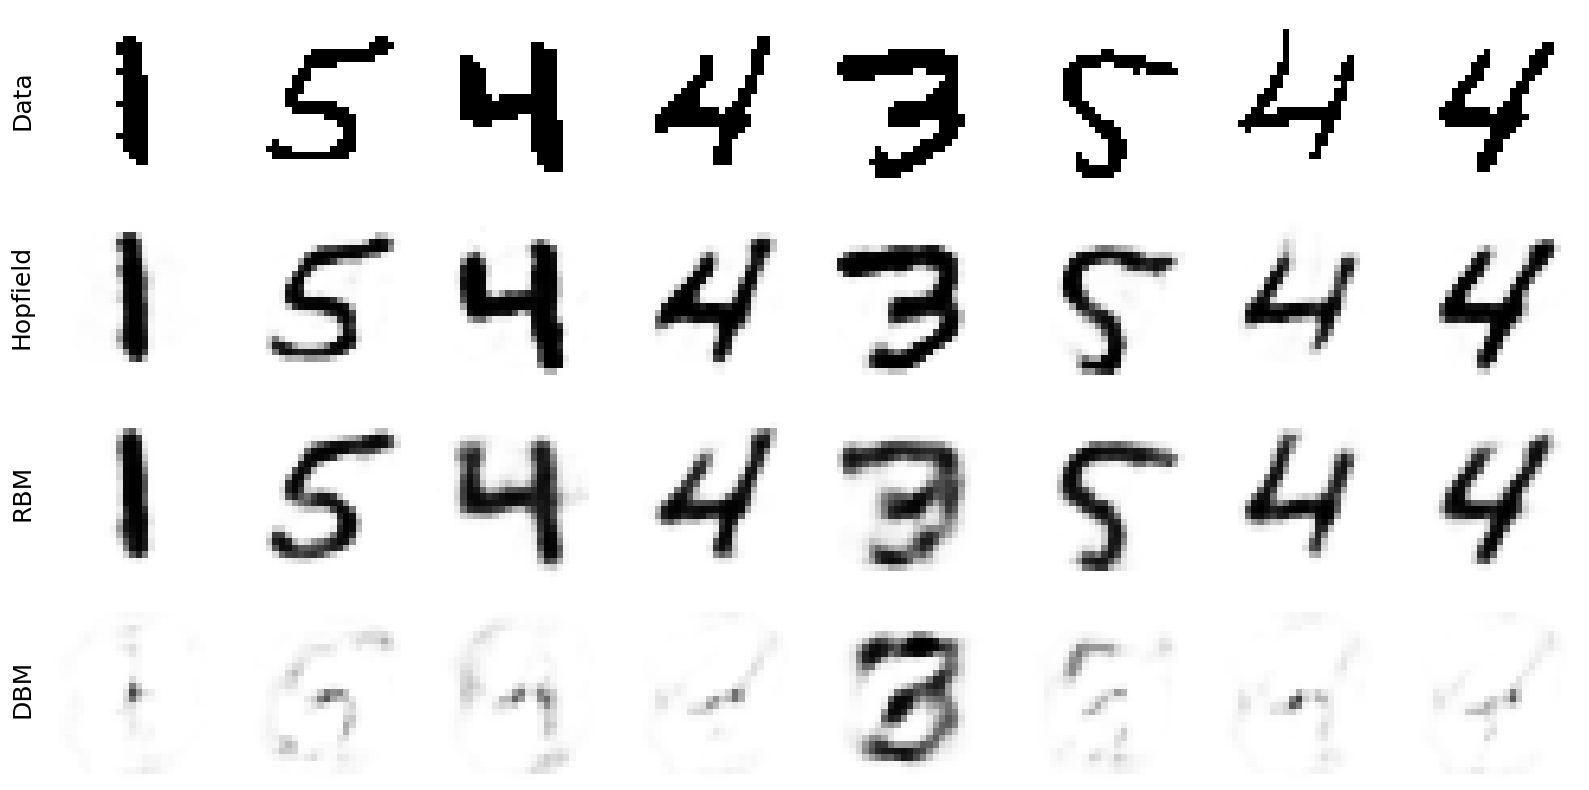

In [10]:
# compute reconstructions
def compute_reconstructions(model, data):
    """
    Computes mean-field reconstructions of the input data.
    One pass up (v -> h) then one pass down (h -> v').

    Args:
        model : an RBM or DBM instance
        data  : numpy array of shape (num_samples, num_visible_units)

    Returns:
        numpy array of shape (num_samples, num_visible_units)
    """
    with torch.no_grad():
        v = torch.tensor(data, dtype=torch.float32, device=device)
        return model.reconstruct(v).cpu().numpy()


# grab a fixed validation batch to use throughout all visualisations
val_tensor, _ = next(iter(val_loader))
examples_val  = val_tensor.numpy()   # shape (batch_size, 784)

hopfield_reconstructions = compute_reconstructions(hopfield, examples_val[:num_to_plot])
rbm_reconstructions      = compute_reconstructions(rbm,      examples_val[:num_to_plot])
dbm_reconstructions      = compute_reconstructions(dbm,      examples_val[:num_to_plot])

reconstruction_plot = plot_image_grid(
    np.array([examples_val[:num_to_plot],
              hopfield_reconstructions,
              rbm_reconstructions,
              dbm_reconstructions]),
    image_shape, vmin=0, vmax=1,
    row_titles=["Data", "Hopfield", "RBM", "DBM"]
)

## Fantasy Particles

Once we have the trained models ready, we can use Monte Carlo to draw samples from the corresponding probability distributions, called "fantasy particles". To this end let us draw a `random_sample` from the validation data, and compute the `model_state`. Next, we define a MC `sampler` based on the `model`, and set its state to `model_state`. To compute the fantasy particles, we do layer-wise Gibbs sampling for a total of `n_steps` equilibration steps. The last step (controlled by the boolean `mean_field`) is a final mean-field iteration.

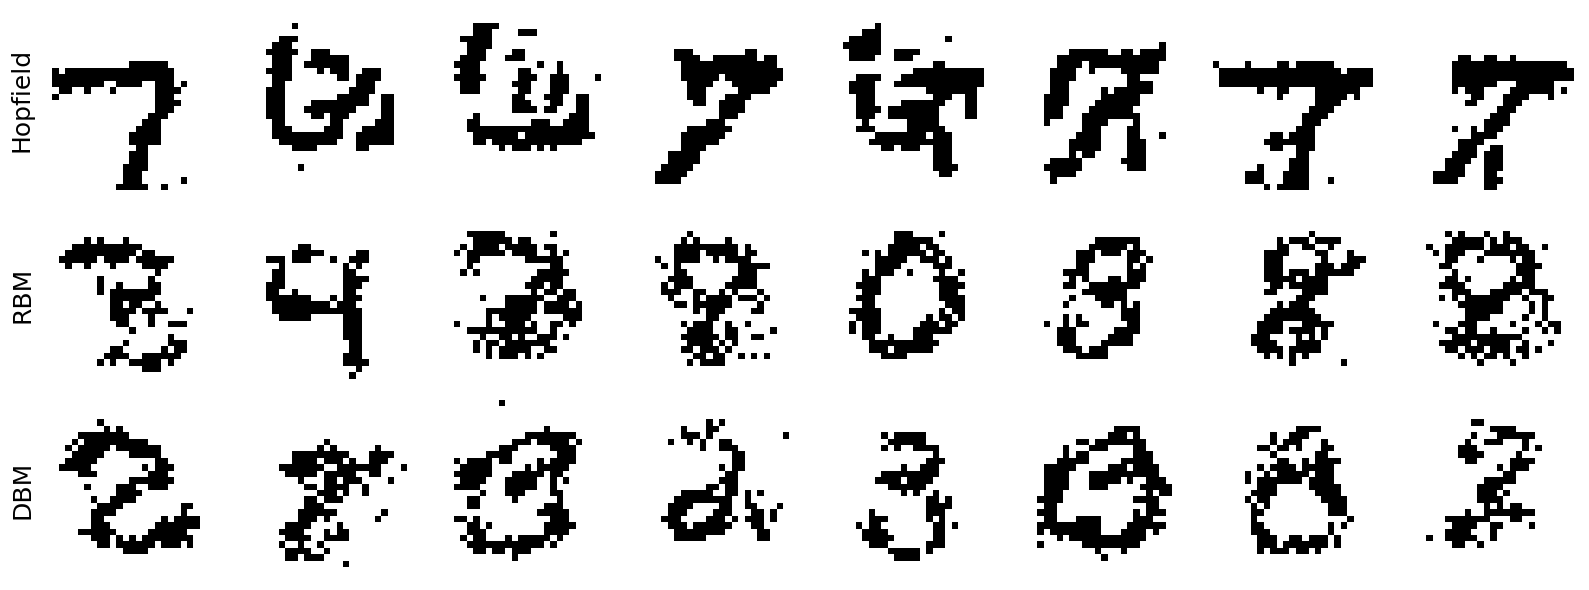

In [11]:
def compute_fantasy_particles(model, num_fantasy, num_steps, mean_field=True):
    """
    Draws samples from the model using block Gibbs sampling MCMC.
    Starts from randomly initialised binary states.

    Args:
        model       : an RBM or DBM instance
        num_fantasy : number of fantasy particles to generate
        num_steps   : number of block Gibbs steps (equilibration steps)
        mean_field  : if True, return mean-field probabilities after the
                      final Gibbs step rather than binary samples

    Returns:
        numpy array of shape (num_fantasy, num_visible_units)
    """
    with torch.no_grad():
        n_vis = (model.n_visible if isinstance(model, RBM)
                 else model.layer_sizes[0])

        # Start from random binary visible states
        v = (torch.rand(num_fantasy, n_vis, device=device) > 0.5).float()

        if isinstance(model, DBM):
            states = [
                (torch.rand(num_fantasy, s, device=device) > 0.5).float()
                for s in model.layer_sizes
            ]
            states[0] = v
            for _ in range(num_steps):
                states = model.gibbs_step(states)
            fantasy_v = model.reconstruct(states[0]) if mean_field else states[0]
        else:
            for _ in range(num_steps):
                h, _ = model.sample_h(v)
                v, _ = model.sample_v(h)
            fantasy_v = model.reconstruct(v) if mean_field else v

    return fantasy_v.cpu().numpy()


hopfield_fantasy = compute_fantasy_particles(hopfield, num_to_plot, 100, mean_field=False)
rbm_fantasy      = compute_fantasy_particles(rbm,      num_to_plot, 100, mean_field=False)
dbm_fantasy      = compute_fantasy_particles(dbm,      num_to_plot, 100, mean_field=False)

fantasy_plot = plot_image_grid(
    np.array([hopfield_fantasy,
              rbm_fantasy,
              dbm_fantasy]),
    image_shape, vmin=0, vmax=1,
    row_titles=["Hopfield", "RBM", "DBM"]
)

## Weight Visualization

Now we can open up the black box of our generative models, in an effort to interpret their behavior. Below, we show the features learned by the weights of the different models.

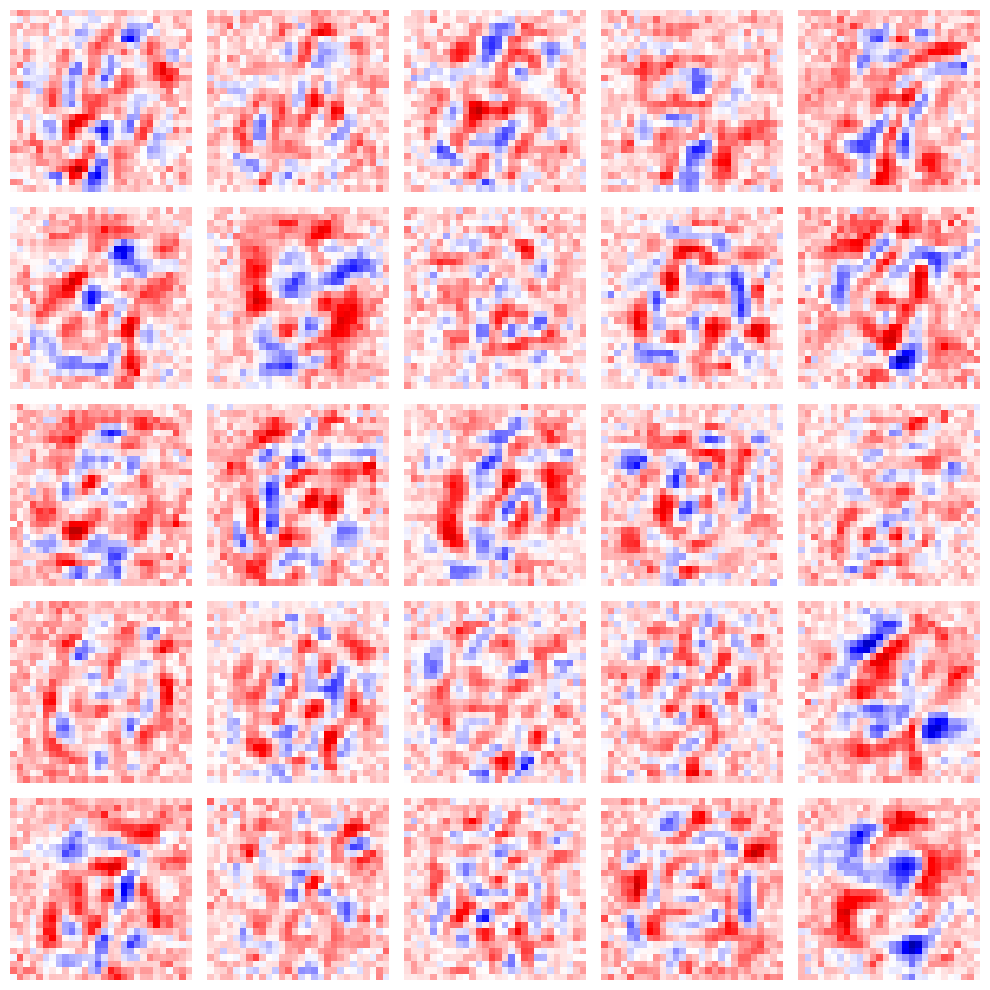

In [12]:
# plot the weights of the hopfield model
# W has shape (n_visible, n_hidden); each column W[:, mu] is a learned feature vector
W_hop = hopfield.W.detach().cpu().numpy()   # (784, 200)
hopfield_weights = plot_image_grid(
    W_hop.T[:25].reshape(5, 5, 784),        # first 25 features -> (5, 5, 784)
    image_shape,
    vmin=W_hop.min(), vmax=W_hop.max(),
    cmap=cm.seismic
)

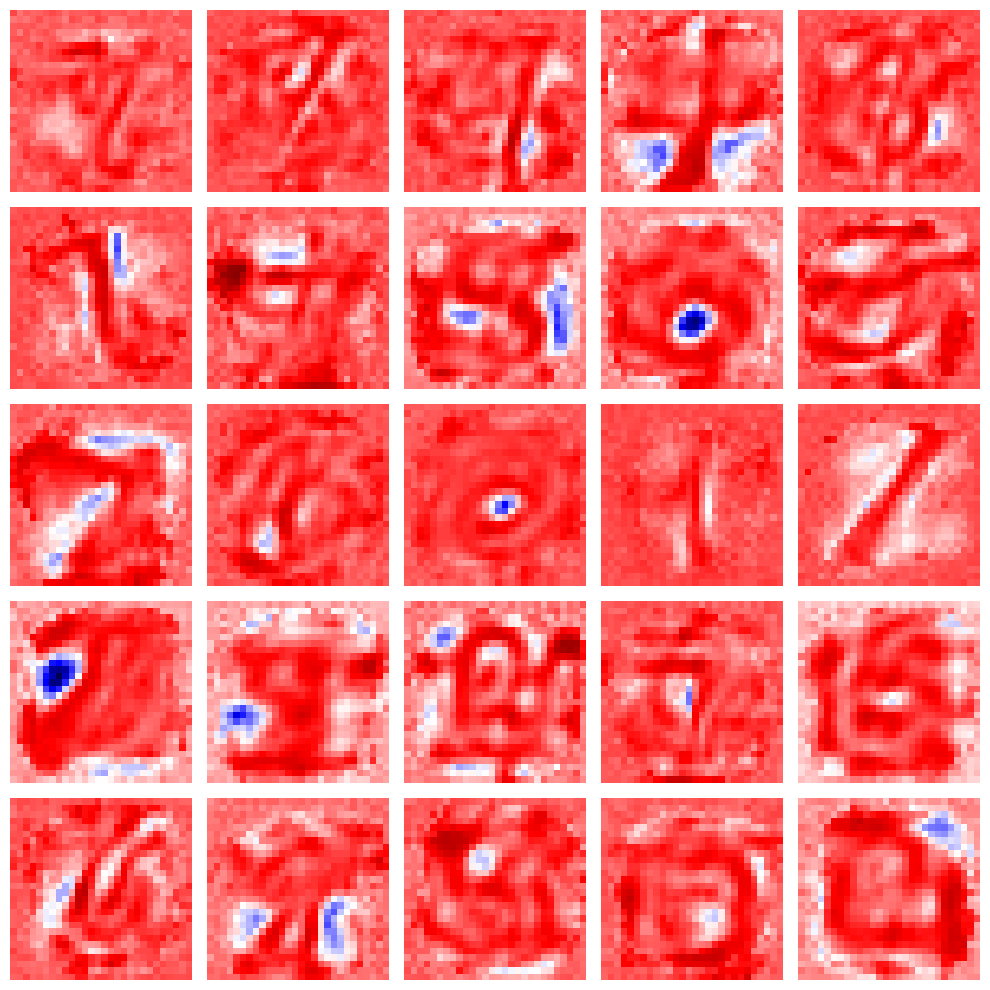

In [13]:
# plot the weights of the RBM
W_rbm = rbm.W.detach().cpu().numpy()
rbm_weights = plot_image_grid(
    W_rbm.T[:25].reshape(5, 5, 784),
    image_shape,
    vmin=W_rbm.min(), vmax=W_rbm.max(),
    cmap=cm.seismic
)

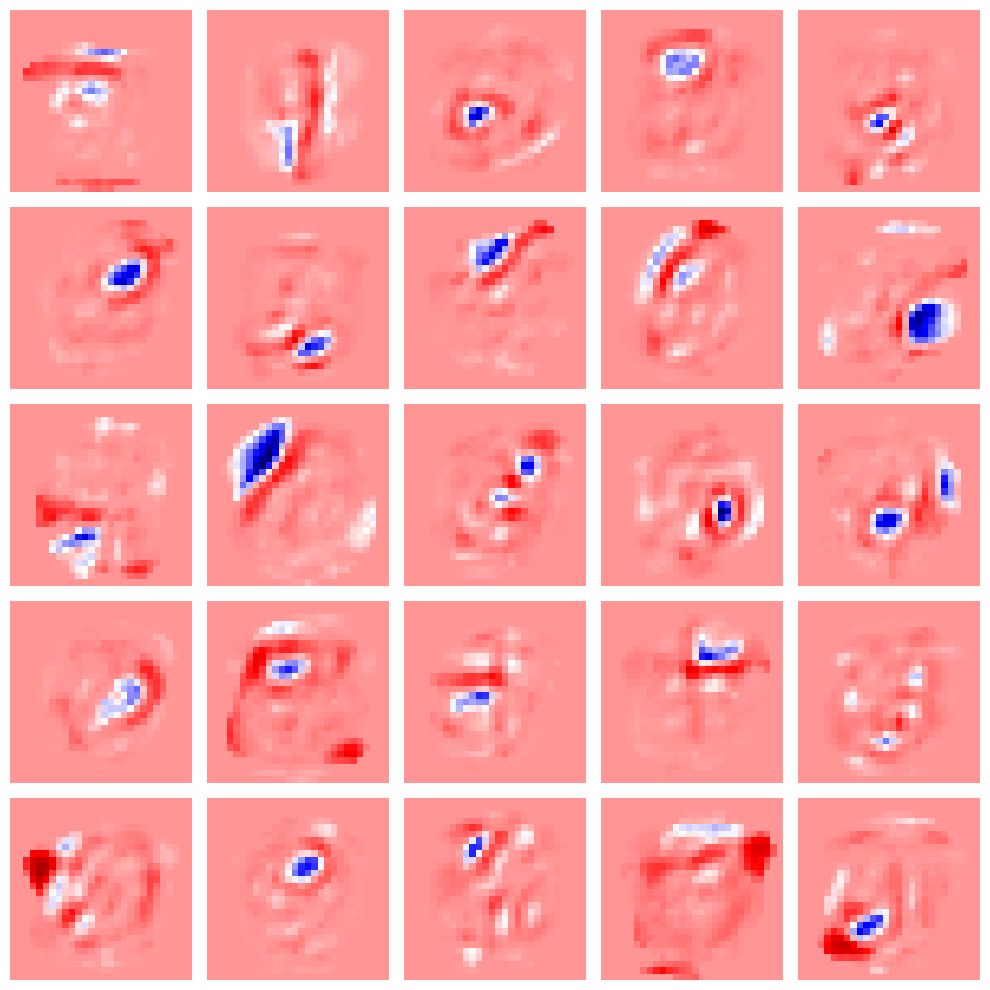

In [14]:
# plot the weights of the first layer of the DBM
W_dbm = dbm.W[0].detach().cpu().numpy()
dbm_weights = plot_image_grid(
    W_dbm.T[:25].reshape(5, 5, 784),
    image_shape,
    vmin=W_dbm.min(), vmax=W_dbm.max(),
    cmap=cm.seismic
)